# Week 8: Handwritten Digit Recognition (MNIST CSV Dataset)
This notebook demonstrates building an Artificial Neural Network (ANN) to classify handwritten digits using the MNIST dataset in CSV format.  

We will cover:
- Loading CSV train and test datasets
- Preprocessing
- Building ANN model
- Training and evaluation
- Visualizations

In [7]:
# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

## 2️⃣ Load Train and Test CSVs
We are using the MNIST dataset in CSV format uploaded on Kaggle.

In [8]:
train_path = '/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv'
test_path = '/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv'

# Load datasets using pandas
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Quick look
train_data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Check shapes
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (60000, 785)
Test shape: (10000, 785)


## 3️⃣ Preprocessing
- Pixel values are normalized (0-255 → 0-1)
- Labels are one-hot encoded for ANN

In [10]:
# Features: all columns except 'label'
X_train = train_data.drop('label', axis=1).values / 255.0
X_test = test_data.drop('label', axis=1).values / 255.0

# Labels: 'label' column
y_train = to_categorical(train_data['label'], 10)
y_test = to_categorical(test_data['label'], 10)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (60000, 784)
y_train shape: (60000, 10)


## 4️⃣ Build ANN Model
- Input layer: 784 nodes (28x28 pixels)
- Hidden layers: 2 layers, 128 neurons, ReLU activation
- Dropout: 0.2 for regularization
- Output layer: 10 nodes (Softmax)
- Loss: categorical_crossentropy
- Optimizer: Adam

In [11]:
model = Sequential([
    Dense(128, input_shape=(784,), activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5️⃣ Train Model
- Validation split: 10%
- Epochs: 10
- Batch size: 32

In [12]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8364 - loss: 0.5431 - val_accuracy: 0.9662 - val_loss: 0.1150
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9495 - loss: 0.1629 - val_accuracy: 0.9740 - val_loss: 0.0831
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9628 - loss: 0.1231 - val_accuracy: 0.9770 - val_loss: 0.0753
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9672 - loss: 0.1027 - val_accuracy: 0.9810 - val_loss: 0.0692
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9744 - loss: 0.0870 - val_accuracy: 0.9792 - val_loss: 0.0720
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9771 - loss: 0.0755 - val_accuracy: 0.9793 - val_loss: 0.0715
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9771 - loss: 0.0678 - val_accuracy: 0.9815 - val_loss: 0.0676
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9782 - loss: 0.0675 - 

## 6️⃣ Evaluate Model

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9745 - loss: 0.0888
Test Accuracy: 0.979200005531311
Test Loss: 0.07241407781839371


## 7️⃣ Visualize Training History

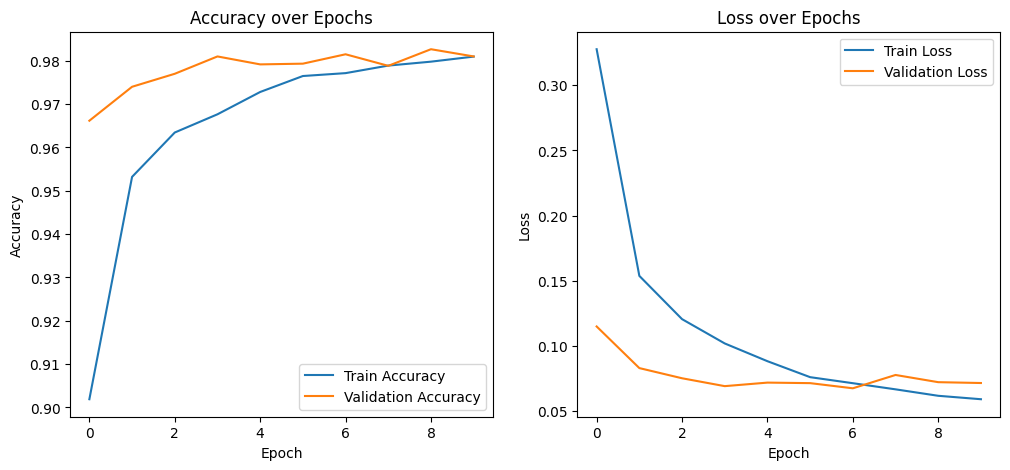

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

## 8️⃣ Sample Predictions
Visualize some handwritten digits along with predictions.

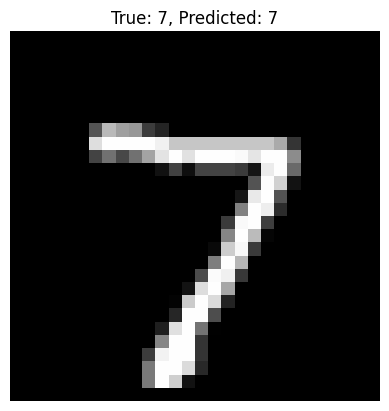

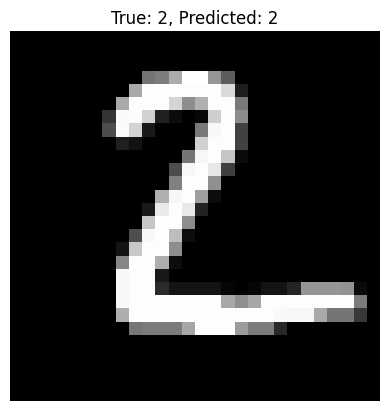

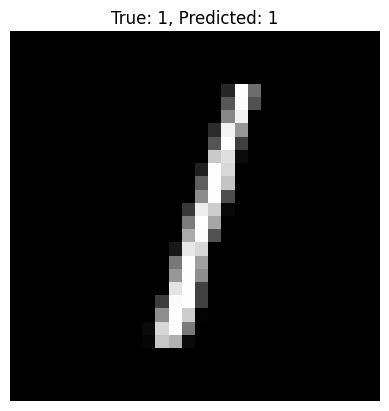

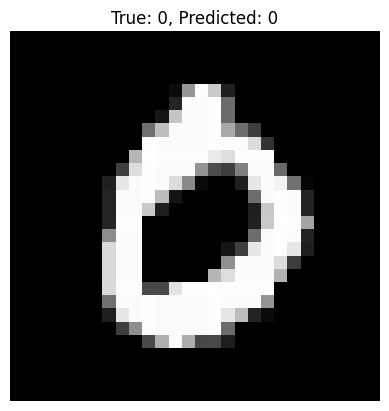

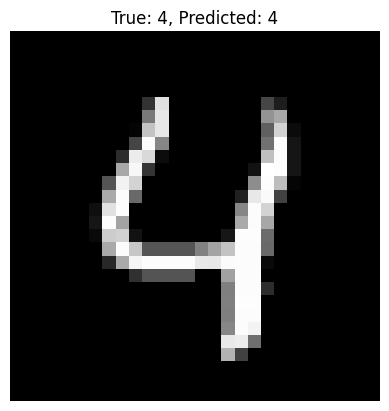

In [15]:
for i in range(5):
    img = X_test[i].reshape(28,28)
    true_label = np.argmax(y_test[i])
    pred_label = np.argmax(model.predict(X_test[i:i+1], verbose=0))
    
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}, Predicted: {pred_label}")
    plt.axis('off')
    plt.show()

## 9️⃣ Key Takeaways
- Correctly loading CSVs is crucial; `np.load()` is only for `.npy`/`.npz`.
- Normalizing pixel values and one-hot encoding labels improves training.
- Dropout layers help prevent overfitting.
- Monitoring accuracy/loss helps with tuning epochs and architecture.

Next steps: CNNs, data augmentation, transfer learning for more complex datasets.